# `geom_gauge()`

`geom_gauge()` draws a semicircle gauge at a given (`x`, `y`) position.

It is useful for KPI indicators and dashboard-style summaries.

Important: `value` is a mapped aesthetic, while `hole` is a layer parameter.
So different gauge values can be drawn in a single `geom_gauge()` layer.

In [1]:
from lets_plot import *


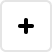
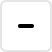
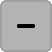
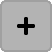
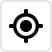
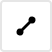
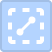
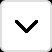
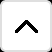
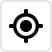
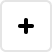
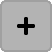
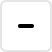
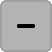
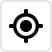
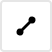
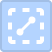
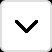
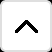
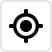

In [2]:
LetsPlot.setup_html()

## 1. Basic gauge

In [3]:
basic_df = {'x': [0], 'y': [0], 'value': [0.72], 'label': ['72%']}

(
    ggplot(basic_df, aes('x', 'y', value='value'))
    + geom_gauge(hole=0.45, size=42, fill='#2E7D32', color='#FF0000', stroke=1.2)
    + geom_text(aes(label='label'), y=0.05, size=11, fontface='bold')
    + coord_fixed()
    + xlim(-1.1, 1.1)
    + ylim(-0.35, 1.05)
    + theme_void()
    + ggtitle('Simple KPI Gauge')
)

## 2. `value` aesthetic controls the filled arc

In [4]:
def gauge_by_value(value, title, color):
    df = {'x': [0], 'y': [0], 'value': [value]}
    return (
        ggplot(df, aes('x', 'y', value='value'))
        + geom_gauge(hole=0.5, size=24, fill=color, color='#2F3640', stroke=1.0)
        + coord_fixed()
        + xlim(-1.1, 1.1)
        + ylim(-0.35, 1.05)
        + theme_void()
        + ggtitle(title)
    )

gggrid([
    gauge_by_value(0.2, 'Low', '#D32F2F'), gauge_by_value(0.55, 'Medium', '#F9A825'), gauge_by_value(0.9, 'High', '#2E7D32')
])

## 3. Gauge shape: `hole` and `size`

In [5]:
def gauge_shape(hole, size, title):
    return (
        ggplot({'x': [0], 'y': [0], 'value': [0.65]}, aes('x', 'y', value='value')) +
        geom_gauge(hole=hole, size=size, fill='#F57C00') +
        coord_fixed() +
        xlim(-1, 1) + ylim(-0.2, 1.0) +
        ggtitle(title) +
        theme_void() +
        theme(plot_title=element_text(hjust=0.5))
    )

gggrid([
    gauge_shape(hole=0.3, size=10, title='hole=0.3, size=20'),
    gauge_shape(hole=0.8, size=20, title='hole=0.8, size=20'),
    gauge_shape(hole=0.3, size=30, title='hole=0.3, size=30'),
    gauge_shape(hole=0.8, size=30, title='hole=0.8, size=30'),
], ncol=2)

## 4. KPI board with mapped `value`

In [6]:
kpi_data = [
    {'metric': 'Availability', 'x': 0.0, 'y': 0.0, 'value': 0.94, 'label': '94%', 'fill': '#2E7D32'},
    {'metric': 'Quality',      'x': 1.6, 'y': 0.0, 'value': 0.78, 'label': '78%', 'fill': '#F9A825'},
    {'metric': 'Delivery',     'x': 3.2, 'y': 0.0, 'value': 0.61, 'label': '61%', 'fill': '#EF6C00'},
]

kpi_data

[{'metric': 'Availability',
  'x': 0.0,
  'y': 0.0,
  'value': 0.94,
  'label': '94%',
  'fill': '#2E7D32'},
 {'metric': 'Quality',
  'x': 1.6,
  'y': 0.0,
  'value': 0.78,
  'label': '78%',
  'fill': '#F9A825'},
 {'metric': 'Delivery',
  'x': 3.2,
  'y': 0.0,
  'value': 0.61,
  'label': '61%',
  'fill': '#EF6C00'}]

In [7]:
kpi_df = {k: [row[k] for row in kpi_data] for k in kpi_data[0]}

p = (
    ggplot(kpi_df, aes('x', 'y', value='value'))
    + geom_gauge(
        aes(fill='fill'),
        hole=0.52,
        size=10,
        color='#263238',
        stroke=1.0,
        tooltips=layer_tooltips().line('Metric|@metric').line('Value|@label')
    )
    + geom_text(aes('x', label='label'), y=0.72, size=9.5, fontface='bold')
    + geom_text(aes('x', label='metric'), y=-0.20, size=8.0)
    + coord_fixed()
    + xlim(-0.8, 4.0)
    + ylim(-0.35, 1.1)
    + theme_void()
    + scale_fill_identity()
)

p + ggtitle('KPI Board')

## 5. Scatter gauge on livemap

In [42]:
stations = [
    {"station": "Penn Station",       "lon": -73.9940, "lat": 40.7506, "capacity": 42, "bikes": 35},
    {"station": "Times Sq - W 41 St", "lon": -73.9874, "lat": 40.7551, "capacity": 35, "bikes": 19},
    {"station": "Bryant Park",        "lon": -73.9830, "lat": 40.7531, "capacity": 31, "bikes": 24},
    {"station": "Union Square",       "lon": -73.9903, "lat": 40.7359, "capacity": 39, "bikes": 12},
    {"station": "Chelsea Market",     "lon": -74.0060, "lat": 40.7424, "capacity": 27, "bikes": 21},
    {"station": "SoHo - Broadway",    "lon": -73.9985, "lat": 40.7241, "capacity": 29, "bikes": 26},
    {"station": "East Village",       "lon": -73.9847, "lat": 40.7262, "capacity": 23, "bikes": 8},
    {"station": "Grand Central",      "lon": -73.9772, "lat": 40.7527, "capacity": 44, "bikes": 38},
]

for station in stations:
    station["value"] = station["bikes"] / station["capacity"]
    station["size"] = 7 + station["capacity"] / 8
    station["fill"] = (
        "red" if station["value"] >= 0.75
        else "orange" if station["value"] >= 0.50
        else "green"
    )

stations_df = {k: [row[k] for row in stations] for k in stations[0]}

p = (
    ggplot(stations_df, aes("lon", "lat", value="value", size="size", fill="fill"))
    + geom_livemap(location=[-73.9895, 40.7425], zoom=13)
    + geom_gauge(
        color="#000080",
        stroke=3,
        size=4,
        tooltips=(
            layer_tooltips()
            .title("@station")
            .format("value", ".0%")
            .line("Bike load|@bikes/@capacity")
            .line("Occupancy|@value")
        )
    )
    + ggsize(950, 560)
    + ggtitle("Manhattan bike stations: occupancy gauges")
    + scale_fill_identity()
    + scale_size_identity()
)

p


## Notes

- `value` is expected in `[0, 1]`.
- `hole` sets the inner radius ratio: `0` gives a solid semicircle, values closer to `1` make a thinner ring.
- `size` controls the gauge diameter.
- Different KPI values can be shown in one `geom_gauge()` layer via `aes(value='value')`.
- With `geom_livemap()`, map `x`/`y` to longitude/latitude.